In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

In [26]:
limit= 20_000
offset= 40_000

url= f'https://data.cityofnewyork.us/resource/k397-673e.json?$offset={offset}&$limit={limit}'
response= requests.get(url)

In [27]:
response_json = response.json()

In [28]:
df= pd.DataFrame(response_json)
df.head()

,fiscal_year,payroll_number,agency_name,last_name,first_name,mid_init,agency_start_date,work_location_borough,title_description,leave_status_as_of_june_30,base_salary,pay_basis,regular_hours,regular_gross_paid,ot_hours,total_ot_paid,total_other_pay
0,2021,67,ADMIN FOR CHILDREN'S SVCS,MOSLEY,SHATEMIA,M,2017-11-13T00:00:00.000,BROOKLYN,CHILD PROTECTIVE SPECIALIST,ACTIVE,60327.00,per Annum,1543.50,51017.16,53.75,2129.21,967.26
1,2021,67,ADMIN FOR CHILDREN'S SVCS,AKERELE,JULIUS,NaN,2011-07-04T00:00:00.000,MANHATTAN,CLERICAL ASSOCIATE,ACTIVE,48999.00,per Annum,1820.00,48861.00,0.00,0.00,5205.50
2,2021,67,ADMIN FOR CHILDREN'S SVCS,SMALLS,CATHERINE,NaN,2015-03-16T00:00:00.000,MANHATTAN,CLERICAL ASSOCIATE,ACTIVE,48865.00,per Annum,1820.00,48727.37,0.00,1.73,5263.29
3,2021,67,ADMIN FOR CHILDREN'S SVCS,BREWER JR,THOMAS,A,2015-08-17T00:00:00.000,MANHATTAN,PRINCIPAL ADMINISTRATIVE ASSOCIATE - NON SUPVR,ACTIVE,54591.00,per Annum,1820.00,53971.36,0.00,0.00,0.00
4,2021,67,ADMIN FOR CHILDREN'S SVCS,ELEFTHERIOU,MARIA,NaN,2018-06-04T00:00:00.000,MANHATTAN,PRINCIPAL ADMINISTRATIVE ASSOCIATE - NON SUPVR,ACTIVE,54531.00,per Annum,1820.00,53968.71,0.00,0.00,0.00


In [29]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

In [30]:
#checking for null values
df.isna().sum()

fiscal_year                      0
payroll_number                   0
agency_name                      0
last_name                        0
first_name                       0
mid_init                      6593
agency_start_date                0
work_location_borough            0
title_description                0
leave_status_as_of_june_30       0
base_salary                      0
pay_basis                        0
regular_hours                    0
regular_gross_paid               0
ot_hours                         0
total_ot_paid                    0
total_other_pay                  0
dtype: int64

no actual missing values. good so far

In [31]:
#checking data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   fiscal_year                 20000 non-null  object
 1   payroll_number              20000 non-null  object
 2   agency_name                 20000 non-null  object
 3   last_name                   20000 non-null  object
 4   first_name                  20000 non-null  object
 5   mid_init                    13407 non-null  object
 6   agency_start_date           20000 non-null  object
 7   work_location_borough       20000 non-null  object
 8   title_description           20000 non-null  object
 9   leave_status_as_of_june_30  20000 non-null  object
 10  base_salary                 20000 non-null  object
 11  pay_basis                   20000 non-null  object
 12  regular_hours               20000 non-null  object
 13  regular_gross_paid          20000 non-null  ob

In [32]:
#drop unnecessary features first
df= df.drop(['payroll_number', 'last_name',
       'first_name', 'mid_init'], axis= 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   fiscal_year                 20000 non-null  object
 1   agency_name                 20000 non-null  object
 2   agency_start_date           20000 non-null  object
 3   work_location_borough       20000 non-null  object
 4   title_description           20000 non-null  object
 5   leave_status_as_of_june_30  20000 non-null  object
 6   base_salary                 20000 non-null  object
 7   pay_basis                   20000 non-null  object
 8   regular_hours               20000 non-null  object
 9   regular_gross_paid          20000 non-null  object
 10  ot_hours                    20000 non-null  object
 11  total_ot_paid               20000 non-null  object
 12  total_other_pay             20000 non-null  object
dtypes: object(13)
memory usage: 2.0+ MB


In [33]:
#casting data to the right types
num_cols= ['base_salary',  'regular_hours', 'regular_gross_paid', 'ot_hours', 'total_ot_paid','total_other_pay']
cat_cols= ['fiscal_year', 'agency_name', 'work_location_borough', 'leave_status_as_of_june_30', 'pay_basis']

df[num_cols]=  df[num_cols].apply(lambda col: pd.to_numeric(col, errors= 'coerce'))
df[cat_cols]= df[cat_cols].apply(lambda col: col.astype('category'))
df['agency_start_date']= pd.to_datetime(df['agency_start_date'])

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   fiscal_year                 20000 non-null  category      
 1   agency_name                 20000 non-null  category      
 2   agency_start_date           20000 non-null  datetime64[ns]
 3   work_location_borough       20000 non-null  category      
 4   title_description           20000 non-null  object        
 5   leave_status_as_of_june_30  20000 non-null  category      
 6   base_salary                 20000 non-null  float64       
 7   pay_basis                   20000 non-null  category      
 8   regular_hours               20000 non-null  float64       
 9   regular_gross_paid          20000 non-null  float64       
 10  ot_hours                    20000 non-null  float64       
 11  total_ot_paid               20000 non-null  float64   

In [35]:
#transforming agency_start_date to years_worked for better inference
n_years_worked = df['fiscal_year'].astype('int') - df['agency_start_date'].dt.year
df['agency_years_spent']= n_years_worked

df= df.drop(['agency_start_date'], axis= 1)

In [36]:
#checking for impossible values
df[(df[num_cols] < 0).any(axis= 1)]

,fiscal_year,agency_name,work_location_borough,title_description,leave_status_as_of_june_30,base_salary,pay_basis,regular_hours,regular_gross_paid,ot_hours,total_ot_paid,total_other_pay,agency_years_spent
126,2021,ADMIN FOR CHILDREN'S SVCS,MANHATTAN,CONGREG CARE SPEC - ACS,ACTIVE,42731.0,per Annum,1820.0,40988.56,344.25,11141.72,-190.97,5
184,2021,ADMIN FOR CHILDREN'S SVCS,BROOKLYN,CHILD PROTECTIVE SPECIALIST,ACTIVE,60327.0,per Annum,1469.0,51131.73,0.00,0.00,-665.02,5
297,2021,ADMIN FOR CHILDREN'S SVCS,MANHATTAN,DIRECTOR OF HEADSTART PROGRAM,ACTIVE,150000.0,per Annum,595.0,48904.07,0.00,0.00,-574.71,0
398,2021,ADMIN FOR CHILDREN'S SVCS,BROOKLYN,YOUTH DEVELOPMENT SPECIALIST,ACTIVE,49318.0,per Annum,1526.0,46459.87,-2.50,-78.26,106.00,2
485,2021,ADMIN FOR CHILDREN'S SVCS,BROOKLYN,CHILD PROTECTIVE SPECIALIST,ACTIVE,60327.0,per Annum,1253.0,46034.16,40.50,1451.24,-3313.69,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16362,2019,ADMIN FOR CHILDREN'S SVCS,MANHATTAN,CHILD WELFARE SPECIALIST SUPERVISOR,ACTIVE,78763.0,per Annum,1818.0,78529.72,59.00,1741.14,-17.94,2
16881,2019,ADMIN FOR CHILDREN'S SVCS,QUEENS,DIRECTOR OF FIELD OPERATIONS,ACTIVE,103751.0,per Annum,1622.0,87616.86,0.00,-542.97,-902.27,20
16894,2019,ADMIN FOR CHILDREN'S SVCS,MANHATTAN,CHILD WELFARE SPECIALIST SUPERVISOR,ACTIVE,88429.0,per Annum,1825.0,86419.00,0.00,0.00,-75.86,2
16935,2019,ADMIN FOR CHILDREN'S SVCS,MANHATTAN,CHILD WELFARE SPECIALIST,ACTIVE,57260.0,per Annum,1825.0,59692.82,645.00,27769.25,-456.94,2


There are negative values here labelled as Compensation in the documentation of dataset.

We keep it for the purpose of regression. For other purposes like classifiers, we would need to handle it

In [37]:
#creating the target value 
df['net_income']= df['regular_gross_paid'] + df['total_ot_paid'] + df['total_other_pay']

In [38]:
#checking if net income is negative and if so, how many are active
net_income= df[(df['net_income'] < 0)]
print('No. of people with negative income= ', net_income.shape[0])
active_and_neg_income= net_income[net_income['leave_status_as_of_june_30'] == 'ACTIVE']
print('No. of people with negative income= ', active_and_neg_income.shape[0])
print('Total No. of people in the data= ', df.shape[0])

No. of people with negative income=  149
No. of people with negative income=  2
Total No. of people in the data=  20000


In [39]:
X= df.drop(['title_description', 'net_income'] ,axis=1)
y= df['net_income']

In [40]:
num_cols= ['base_salary', 'regular_hours', 'regular_gross_paid', 'ot_hours', 'total_ot_paid',
       'total_other_pay', 'agency_years_spent']
cat_cols= ['fiscal_year', 'agency_name' ,'work_location_borough', 'leave_status_as_of_june_30', 'pay_basis']


In [41]:
num_pipeline= Pipeline(
    [
        ('imputing', SimpleImputer(strategy= 'median')),
        ('scaling', StandardScaler())
    ]
)

cat_pipeline= Pipeline(
    [
        ('imputing', SimpleImputer(strategy= 'constant', fill_value= 'missing')),
        ('encoding', OneHotEncoder(handle_unknown= 'ignore'))
    ]
)

In [42]:
preprocessor= ColumnTransformer(
    [('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)],
    remainder= 'passthrough'
)

pipeline= Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor())
])

In [43]:
X_train, X_test, y_train, y_test= train_test_split(X, y, random_state= 182, test_size= 0.2)

In [44]:
pipeline.fit(X_train, y_train)
y_preds= pipeline.predict(X_test)

In [45]:
print('r2_score = ', r2_score(y_test, y_preds))
print('rmse_score = ', np.sqrt(mean_squared_error(y_test, y_preds)))
print('mae_score = ', mean_absolute_error(y_test, y_preds))

r2_score =  0.9978952086633138
rmse_score =  1648.362848206511
mae_score =  438.7915967250006


<Axes: ylabel='None'>

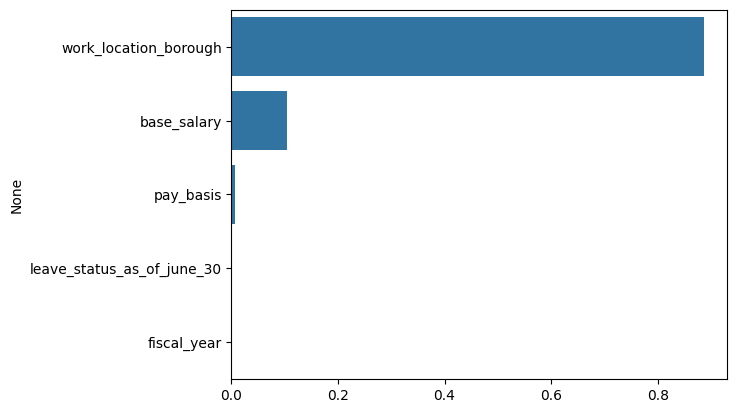

In [46]:
feature_importance= pipeline.named_steps['model'].feature_importances_
top_five_features_idx = feature_importance.argsort()[::-1][:5]
top_five_features= X_train.columns[top_five_features_idx]

sns.barplot(y= top_five_features, x= feature_importance[top_five_features_idx], orient= 'h')

In [47]:
joblib.dump(pipeline, 'new_york_payroll_pipeline.pkl')

['new_york_payroll_pipeline.pkl']